# Bell States

In [1]:
# Quantum computing.
import qiskit

# Quantum simulator.
import qiskit_aer as aer

# For histograms.
import qiskit.visualization as viz

# Qusntum information.
import qiskit.quantum_info as info

## Quantum Circuit

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit

In [2]:
# Quantum circuit with two qubits and two classical bits.
qc = qiskit.QuantumCircuit(2, 2)

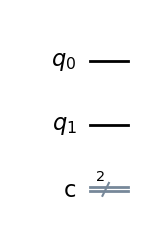

In [3]:
# Show the circuit.
# https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#draw
qc.draw(output='mpl')

## Create Gates

In [4]:
# Add a H gate to the first qubit.
# https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#h
qc.h(0)

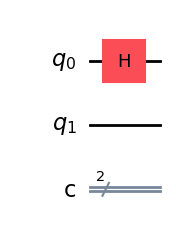

In [5]:
# Show the circuit.
qc.draw(output='mpl')

In [6]:
# Controlled X gate.
# https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#cx
qc.cx(0, 1)

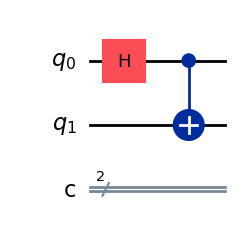

In [7]:
# Show the circuit.
qc.draw(output='mpl')

## Measure

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#measure

In [8]:
# Measure qubit 0 into classical bit 0.
qc.measure(0, 0)

In [9]:
# Measure qubit 1 into classical bit 1.
qc.measure(1, 1)

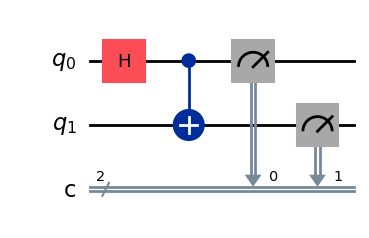

In [10]:
# Show the circuit.
qc.draw(output='mpl')

## Simulate

https://qiskit.github.io/qiskit-aer/

In [11]:
# Initialize the simulator.
# https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html
simulator = aer.AerSimulator()

In [12]:
# Compile our quantum circuit for the simulator.
compiled = qiskit.transpile(qc, simulator)

In [13]:
# Run the circuit.
result = simulator.run(compiled, shots=1024).result()

In [14]:
# Get the results.
counts = result.get_counts()

In [15]:
# Show results.
print(counts)

{'00': 505, '11': 519}


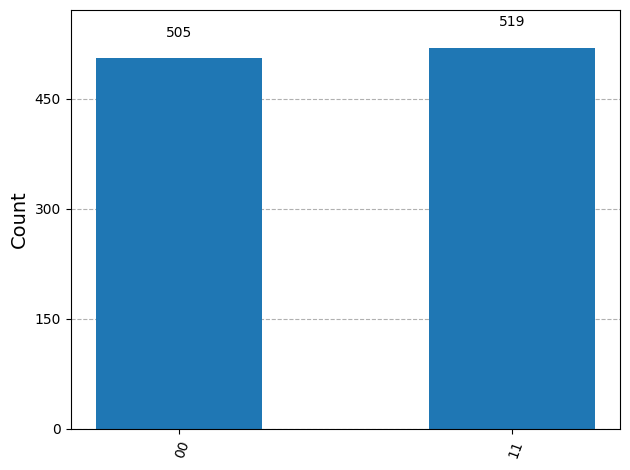

In [16]:
viz.plot_histogram(counts)

## State Vectors

In [17]:
def colvec(qc):
  """Helper function to draw column vectors nicely."""
  # https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.visualization.array_to_latex
  # https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector#from_instruction
  return viz.array_to_latex(info.Statevector.from_instruction(qc).data.reshape(-1, 1))

In [18]:
# Create quantum circuit.
qc = qiskit.QuantumCircuit(2)
colvec(qc)

<IPython.core.display.Latex object>

In [19]:
# Add H gate.
qc.h(0)
colvec(qc)

<IPython.core.display.Latex object>

In [20]:
# Add CX gate.
qc.cx(0, 1)
colvec(qc)

<IPython.core.display.Latex object>

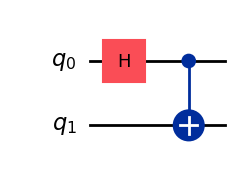

In [21]:
# Draw circuit.
qc.draw(output='mpl')

In [22]:
# Tell the circuit to save the statevectors.
qc.save_statevector()

In [23]:
# Simulator, state vector style.
simulator = aer.AerSimulator(method="statevector")

In [24]:
# Compile.
compiled = qiskit.transpile(qc, simulator)

In [25]:
# Result.
result = simulator.run(compiled).result()

In [26]:
# Show final state vector.
viz.array_to_latex(result.get_statevector().data.reshape(-1, 1))

<IPython.core.display.Latex object>

## End